In [1]:
# ノートブックの環境変数設定
%env DATA_ROOT /home/ryo52/LAIME/atmacup11

env: DATA_ROOT=/home/ryo52/LAIME/atmacup11


In [2]:
import os
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings
from contextlib import contextmanager
import time
from collections import defaultdict
import math

# PyTorch 関連
import torch
from torch import nn
from torch.utils import data
from torchvision import transforms as T
from torch.optim import Adam
from torch.optim.optimizer import Optimizer

# CV と評価
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error

# モデル (timm) とロギング (wandb)
import timm
import wandb

# 警告を非表示に
warnings.filterwarnings('ignore')

# ノートブックで使われていたvivid.utils.timerの代替
@contextmanager
def timer(prefix=""):
    start = time.time()
    yield
    end = time.time()
    print(f"[{prefix}] {end - start:.2f} sec")

print(f"PyTorch Version: {torch.__version__}")
print(f"timm Version: {timm.__version__}")

/home/ryo52/miniconda3/envs/data_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.9.0+cu128
timm Version: 1.0.22


In [ ]:
# ---------------------------------
# 設定 (★必要に応じて変更)
# ---------------------------------
# wandb の設定
WANDB_PROJECT = "atmaCup11-Baseline"
WANDB_ENTITY = "surumen-"  # ★ 自分の wandb の entity (username or team) に変更

# CVの設定 (baseの要求)
N_SPLITS = 5
N_USED_FOLDS = 1  # ★ 使用するFold数 (1 にすれば 1Fold のみで高速検証可能)
RANDOM_STATE = 42

# 学習の設定
N_EPOCHS = 100     # エポック数 (ノートブックより少し長めに設定)
BATCH_SIZE = 64
LR = 1e-3
IMG_SIZE = 224    # モデルに合わせて 224x224

# ---------------------------------
# ディレクトリ設定 (ノートブックの構成を流用)
# ---------------------------------

dataset_root = os.environ.get('DATA_ROOT', './atmacup11') # 環境変数がなければカレント配下を想定

input_dir = os.path.join(dataset_root, "inputs")
photo_dir = os.path.join(input_dir, "photos")

# このベースライン用の出力ディレクトリ
output_dir = os.path.join(dataset_root, "outputs_baseline_resnet18d")
os.makedirs(output_dir, exist_ok=True)

print(f"Input Dir: {input_dir}")
print(f"Output Dir: {output_dir}")

# ---------------------------------
# デバイス設定 (ノートブックの構成を流用)
# ---------------------------------
assert torch.cuda.is_available()
DEVICE = torch.device("cuda")
print(f"DEVICE: {DEVICE}")

Input Dir: /home/ryo52/LAIME/atmacup11/inputs
Output Dir: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d
DEVICE: cuda


In [4]:
train_df = pd.read_csv(os.path.join(input_dir, 'train.csv'))
test_df = pd.read_csv(os.path.join(input_dir, 'test.csv'))
submission_df = pd.read_csv(os.path.join(input_dir, 'atmaCup#11_sample_submission.csv'))

print(f"train_df: {train_df.shape}")
print(f"test_df: {test_df.shape}")
train_df.head()

train_df: (3937, 4)
test_df: (5919, 1)


,object_id,sorting_date,art_series_id,target
0,002bff09b09998d0be65,1631,509357f67692a6a45626,1
1,00309fb1ef05416f9c1f,1900,7987b47bbe5dc3039179,3
2,003a1562e97f79ba96dc,1834,ded7c3c9636708e5b14c,3
3,004890880e8e7431147b,1743,582ac2d7f0cef195b605,2
4,00718c32602425f504c1,1885,64c907f0c08dce4fb8e8,3


In [5]:
# timm のモデルも標準的な正規化パラメータを使用->pretrained=Falseなので不適切
# IMG_MEAN = [0.485, 0.456, 0.406]
# IMG_STD = [0.229, 0.224, 0.225]


def compute_channel_mean_std(image_paths, size=(IMG_SIZE, IMG_SIZE), sample_limit=None):
    """
    image_paths: 画像ファイルパスのリスト（訓練データ）
    size: Resize 後のサイズ（学習時と合わせる）
    sample_limit: サンプリング数の上限（高速化したいとき任意に指定）
    戻り値: (mean_list, std_list)  # 各3チャネルのリスト（0-1スケール）
    """
    tfm = T.Compose([T.Resize(size), T.ToTensor()])  # ToTensor で [0,1] に正規化
    n = 0
    csum = torch.zeros(3, dtype=torch.float64)
    csum_sq = torch.zeros(3, dtype=torch.float64)

    paths = image_paths if sample_limit is None else image_paths[:sample_limit]
    for p in tqdm(paths, desc="Compute mean/std"):
        # 壊れた画像をスキップ
        try:
            x = tfm(Image.open(p).convert("RGB"))
        except Exception:
            continue
        # x: (3, H, W)
        num_pix = x.shape[1] * x.shape[2]
        n += num_pix
        csum += x.reshape(3, -1).sum(dim=1).double()
        csum_sq += (x.reshape(3, -1) ** 2).sum(dim=1).double()

    mean = (csum / n).tolist()
    var = (csum_sq / n - (csum / n) ** 2).tolist()
    std = [math.sqrt(max(v, 0.0)) for v in var]
    return mean, std

In [6]:
def to_img_path(object_id):
    """ノートブックの関数を流用"""
    return os.path.join(photo_dir, f'{object_id}.jpg')

# object_path カラムをDataFrameに追加
train_df['object_path'] = train_df['object_id'].map(to_img_path)
test_df['object_path'] = test_df['object_id'].map(to_img_path)

train_df[['object_id', 'object_path']].head()

# --- CV に入る前に、全訓練画像から mean/std を算出 ---
train_paths_all = train_df["object_path"].tolist()
IMG_MEAN, IMG_STD = compute_channel_mean_std(train_paths_all, size=(IMG_SIZE, IMG_SIZE))
print("Computed mean:", IMG_MEAN)
print("Computed std :", IMG_STD)


Compute mean/std: 100%|██████████| 3937/3937 [00:03<00:00, 1284.77it/s]

Computed mean: [0.7769526180086934, 0.7435693148855076, 0.6702193549108538]
Computed std : [0.16765932117344476, 0.16857963673428294, 0.16975885414071637]


In [7]:
# baseの要求: sorting_date と art_series_id について StratifiedGroupKFold

fold = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# StratifiedGroupKFold の split(X, y, groups) に以下を割り当てます:
# X: データ全体 (train_df)
# y: 層化の基準 (sorting_date をカテゴリ化した target を使用)
# groups: グループ化の基準 (art_series_id)

y_stratify = train_df['target']
groups = train_df['art_series_id']

# train_df に fold カラムを追加
train_df["fold"] = -1
for i, (idx_tr, idx_valid) in enumerate(
    fold.split(X=train_df, y=y_stratify, groups=groups)
):
    train_df.loc[idx_valid, "fold"] = i

print("Fold distribution (based on 'target' derived from 'sorting_date'):")
print(train_df.groupby('fold')['target'].value_counts().unstack().fillna(0))

# baseの要求: 何fold分を使うか選択できるようにする
use_folds = list(range(N_USED_FOLDS))
print(f"\nUsing {N_USED_FOLDS}/{N_SPLITS} folds: {use_folds}")

Fold distribution (based on 'target' derived from 'sorting_date'):
target    0    1    2    3
fold                      
0       102  171  306  199
1        92  188  314  206
2       100  187  284  213
3        94  183  301  207
4        87  167  306  230

Using 1/5 folds: [0]


In [8]:


class AtmaDataset(data.Dataset):
    """
    ノートブックの AtmaDataset をベースに、最小限の Augmentation に変更
    """
    object_path_key = "object_path"
    label_key = "target"

    def __init__(self, meta_df: pd.DataFrame, is_train=True, mean=None, std=None):
        self.is_train = is_train
        self.meta_df = meta_df.reset_index(drop=True)
        self.index_to_data = self.meta_df.to_dict(orient="index")
        self.mean = mean
        self.std = std

        size = (IMG_SIZE, IMG_SIZE)
        if is_train:
            self.transformer = T.Compose([
                T.Resize(size),
                T.RandomHorizontalFlip(p=0.5),
                T.ToTensor(),
                # 訓練データから計算した mean/std で正規化
                T.Normalize(mean=self.mean, std=self.std) if (self.mean and self.std) else T.Lambda(lambda x: x)
            ])
        else:
            self.transformer = T.Compose([
                T.Resize(size),
                T.ToTensor(),
                # 訓練データから計算した mean/std で正規化
                T.Normalize(mean=self.mean, std=self.std) if (self.mean and self.std) else T.Lambda(lambda x: x)
            ])

    def __getitem__(self, index):
        data = self.index_to_data[index]
        obj_path = data.get(self.object_path_key)
        label = data.get(self.label_key, -1) # test時は -1
        
        img = Image.open(obj_path)
        img = self.transformer(img)
        
        # 評価指標(RMSE)は回帰タスクのため、MSELoss を使う
        # label (target 0,1,2,3) を float tensor に変換
        return img, torch.tensor(label, dtype=torch.float32)

    def __len__(self):
        return len(self.meta_df)

In [9]:
def create_model():
    # baseの要求: timmのresnet18dを用いる
    # 禁止事項: 事前学習済みモデルは利用禁止 (pretrained=False)
    model = timm.create_model(
        "resnet18d", 
        pretrained=False, 
        num_classes=0  # プーリング層の直後までの特徴量を取得
    )

    # Global Average Pooling (gap) 後の特徴量数を取得 (resnet18d は 512)
    in_features = model.num_features 
    
    # 評価指標(RMSE)のため、最終層を 1 (回帰) に変更
    model.fc = nn.Linear(in_features=in_features, out_features=1, bias=True)
    
    return model

# 動作確認
model_check = create_model()
print(f"Model: resnet18d, InFeatures: {model_check.num_features}")
# print(model_check.fc)

Model: resnet18d, InFeatures: 512


In [10]:
# ---------------------------------
# 学習関数 (base: wandb logging)
# ---------------------------------
def train_epoch(
    model: nn.Module,
    optimizer: Optimizer,
    train_loader: data.DataLoader,
    epoch: int,
    device: torch.device
) -> pd.Series:

    model.train()
    criterion = nn.MSELoss() # 評価指標(RMSE)の計算用にMSELossを使用
    metrics = defaultdict(float)
    n_iters = len(train_loader)
    
    for i, (x_i, y_i) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} Train")):
        x_i = x_i.to(device)
        y_i = y_i.to(device).reshape(-1, 1) # MSELoss (N, 1)
        
        output = model(x_i)
        loss = criterion(output, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        metrics["loss"] += loss.item()
        
        # baseの要求: CV時はwandbでlossを可視化 (Stepごと)
        if wandb.run:
            wandb.log({"train_step_loss": loss.item()})

    metrics["loss"] /= n_iters
    return pd.Series({"train_loss": metrics["loss"]})

# ---------------------------------
# 予測関数 (ノートブックの predict を流用)
# ---------------------------------
def predict(model: nn.Module, loader: data.DataLoader, device: torch.device) -> np.ndarray:
    model.eval()
    predicts = []
    
    for x_i, _ in tqdm(loader, desc="Predict"):
        with torch.no_grad():
            output = model(x_i.to(device))
        predicts.extend(output.data.cpu().numpy())

    return np.array(predicts).reshape(-1)

# ---------------------------------
# 評価関数 (ノートブックの calculate_metrics を流用)
# ---------------------------------
def calculate_metrics(y_true, y_pred) -> dict:
    # 評価指標: RMSE
    return {
        'rmse': mean_squared_error(y_true, y_pred) ** .5
    }

# ---------------------------------
# 検証関数 (ノートブックの valid を流用)
# ---------------------------------
def valid_epoch(
    model: nn.Module, 
    y_valid: np.ndarray, 
    valid_loader: data.DataLoader,
    device: torch.device
) -> tuple[pd.Series, np.ndarray]:

    pred = predict(model, valid_loader, device)
    score = calculate_metrics(y_valid, pred)
    
    valid_score = pd.Series(score)
    return valid_score.add_prefix("valid_"), pred

In [11]:
def get_fold_output_dir(n_fold: int):
    """ノートブックの get_output_dir を流用"""
    dir_path = os.path.join(output_dir, f'resnet18d_fold{n_fold}')
    os.makedirs(dir_path, exist_ok=True)
    return dir_path

def run_fold(
    train_df: pd.DataFrame, 
    n_fold: int, 
    n_epochs=N_EPOCHS
) -> tuple[np.ndarray, np.ndarray]:
    """
    ノートブックの run_fold をベースに、wandb と要求仕様を反映
    """
    
    # 1. wandb の初期化 (baseの要求)
    try:
        wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"fold-{n_fold}-resnet18d-epochs{n_epochs}",
            group="resnet18d-baseline",
            config={
                "fold": n_fold,
                "n_epochs": n_epochs,
                "lr": LR,
                "batch_size": BATCH_SIZE,
                "model_name": "resnet18d",
                "cv_strategy": "StratifiedGroupKFold",
                "cv_y": "target",
                "cv_groups": "art_series_id"
            }
        )
    except Exception as e:
        print(f"wandb.init failed: {e}\nLogin using 'wandb login'")
        # wandb login が失敗しても学習は続行する
        pass


    output_fold_dir = get_fold_output_dir(n_fold)
    print(f"--- Fold {n_fold} (Output: {output_fold_dir}) ---")

    # 2. データの準備 (train / valid)
    df_train = train_df[train_df["fold"] != n_fold].copy()
    df_valid = train_df[train_df["fold"] == n_fold].copy()
    y_valid = df_valid['target'].values # 検証用ラベル (target)

    train_dataset = AtmaDataset(meta_df=df_train, is_train=True,  mean=IMG_MEAN, std=IMG_STD)
    valid_dataset = AtmaDataset(meta_df=df_valid, is_train=False, mean=IMG_MEAN, std=IMG_STD)


    train_loader = data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4
    )
    valid_loader = data.DataLoader(
        valid_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=4
    )

    # 3. モデル、Optimizerの準備
    model = create_model()
    model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=LR)

    # 4. 学習ループ
    score_df = pd.DataFrame()
    valid_best_score = np.inf
    valid_best_pred = None
    model_best_path = os.path.join(output_fold_dir, 'model_best.pth')

    for epoch in range(1, n_epochs + 1):
        with timer(prefix=f"Fold {n_fold} Epoch {epoch} Train"):
            score_train = train_epoch(model, optimizer, train_loader, epoch, DEVICE)

        with timer(prefix=f"Fold {n_fold} Epoch {epoch} Valid"):
            score_valid, y_valid_pred = valid_epoch(model, y_valid, valid_loader, DEVICE)
        
        # --- スコアの記録
        row = pd.concat([score_train, score_valid])
        row["epoch"] = epoch
        score_df = pd.concat([score_df, pd.DataFrame([row])], ignore_index=True)
        
        # 5. wandb への Epoch ごとの log (baseの要求)
        if wandb.run:
            wandb.log({
                "epoch": epoch,
                "train_loss": score_train["train_loss"],
                "valid_rmse": score_valid["valid_rmse"]
            })
        
        print(row.to_string(index=False))

        # --- モデルの保存 (ノートブックと同様)
        current_score = score_valid["valid_rmse"]
        if current_score < valid_best_score:
            print(f'Validation score improved! {valid_best_score:.4f} -> {current_score:.4f}')
            torch.save(model.state_dict(), model_best_path)
            valid_best_score = current_score
            valid_best_pred = y_valid_pred

    # 6. wandb の終了
    if wandb.run:
        wandb.finish()
    
    score_df.to_csv(os.path.join(output_fold_dir, 'score.csv'), index=False)
    print(f"Fold {n_fold} Best RMSE: {valid_best_score:.4f}")
    
    # OOF計算用に valid の index と best prediction を返す
    return df_valid.index.values, valid_best_pred

In [12]:
# ---------------------------------
# CV 実行
# ---------------------------------

# (初回実行時、または環境変数 WANDB_API_KEY が設定されていない場合)
# wandb.login() 

# OOF (Out-of-Fold) 予測値を保存する配列
oof = np.zeros((len(train_df),), dtype=np.float32)

# baseの要求: 何fold分を使うか選択できるようにする (use_folds を使用)
for n_fold in use_folds:
    idx_valid, oof_i = run_fold(
        train_df=train_df,
        n_fold=n_fold,
        n_epochs=N_EPOCHS
    )
    oof[idx_valid] = oof_i

# ---------------------------------
# OOFスコアの計算
# ---------------------------------
# 学習に使用した Fold のみで OOF スコアを計算
oof_target_indices = train_df[train_df["fold"].isin(use_folds)].index

if len(oof_target_indices) > 0:
    oof_score = calculate_metrics(
        train_df['target'].values[oof_target_indices], 
        oof[oof_target_indices]
    )

    print(f"\n--- Overall OOF Score ({N_USED_FOLDS} folds) ---")
    print(f"OOF RMSE: {oof_score['rmse']:.4f}")

    # OOF予測値を保存
    oof_df = pd.DataFrame({
        "object_id": train_df["object_id"],
        "target": train_df["target"],
        "oof_pred": oof
    })
    oof_df.to_csv(os.path.join(output_dir, f"oof_pred_resnet18d_{N_USED_FOLDS}folds.csv"), index=False)
else:
    print("\nNo folds were trained. OOF score cannot be calculated.")

wandb: Currently logged in as: surumen (surumen-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--- Fold 0 (Output: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d/resnet18d_fold0) ---


Epoch 1 Train: 100%|██████████| 49/49 [00:06<00:00,  7.02it/s]


[Fold 0 Epoch 1 Train] 7.02 sec


Predict: 100%|██████████| 7/7 [00:04<00:00,  1.63it/s]


...

[Fold 0 Epoch 100 Train] 3.35 sec


Predict: 100%|██████████| 7/7 [00:00<00:00,  8.00it/s]


[Fold 0 Epoch 100 Valid] 0.91 sec
  0.050489
  0.783222
100.000000


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
train_loss,█▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_step_loss,▇█▇▇▇▆▆▇▄▅▆▄▂▃▂▂▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
valid_rmse,▅▇▃▃▄▃▂▄▃█▄▃▃▂▃▃▂▂▃▂▂▁▁▂▁▂▂▁▁▁▃▁▂▁▁▁▁▁▁▁
epoch,100
train_loss,0.05049
train_step_loss,0.24502
valid_rmse,0.78322


Fold 0 Best RMSE: 0.7705

--- Overall OOF Score (1 folds) ---
OOF RMSE: 0.7705


Loading model from: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d/resnet18d_fold0/model_best.pth


Predict: 100%|██████████| 47/47 [00:03<00:00, 13.04it/s]


[Pred Fold=0] 3.64 sec

Submission file saved to: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d/submission_resnet18d_normalized100epoch_1folds.csv
     target
0  1.249370
1  2.250165
2  1.656589
3  0.811033
4  0.427598


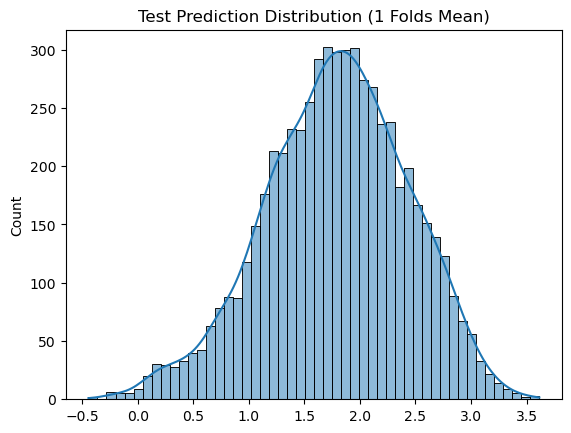

In [13]:
# ---------------------------------
# Testデータセットの準備
# ---------------------------------
test_meta_df = test_df[["object_id", "object_path"]].copy()
test_dataset = AtmaDataset(meta_df=test_meta_df, is_train=False, mean=IMG_MEAN, std=IMG_STD)
test_loader  = data.DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE * 2,
    drop_last=False,
    num_workers=4
)


# ---------------------------------
# 予測の実行 (ノートブックと同様)
# ---------------------------------
test_predictions = []

if len(use_folds) == 0:
    print("No folds trained. Cannot create submission.")
else:
    # N_USED_FOLDS 分のモデルで予測
    for n_fold in use_folds:
        output_fold_dir = get_fold_output_dir(n_fold)
        model_path = os.path.join(output_fold_dir, 'model_best.pth')
        
        if not os.path.exists(model_path):
            print(f"Warning: Model not found for fold {n_fold}. Skipping.")
            continue
            
        print(f"Loading model from: {model_path}")
        
        model = create_model()
        model.load_state_dict(torch.load(model_path))
        model.to(DEVICE)
        
        with timer(prefix=f'Pred Fold={n_fold}'):
            y_pred_i = predict(model, loader=test_loader, device=DEVICE)
        
        test_predictions.append(y_pred_i)

    # ---------------------------------
    # Submission ファイルの作成
    # ---------------------------------
    if len(test_predictions) > 0:
        # 学習に使用したFoldの予測値の平均を取る
        pred_mean = np.array(test_predictions).mean(axis=0)

        # sample_submission.csv の 'target' を置き換える
        submission_df['target'] = pred_mean

        submission_path = os.path.join(output_dir, f"submission_resnet18d_normalized{N_EPOCHS}epoch_{N_USED_FOLDS}folds.csv")
        submission_df.to_csv(submission_path, index=False)

        print(f"\nSubmission file saved to: {submission_path}")
        print(submission_df.head())

        # 予測値の分布確認
        sns.histplot(pred_mean, bins=50, kde=True)
        plt.title(f"Test Prediction Distribution ({N_USED_FOLDS} Folds Mean)")
        plt.show()
    else:
        print("No models were loaded. Cannot create submission file.")

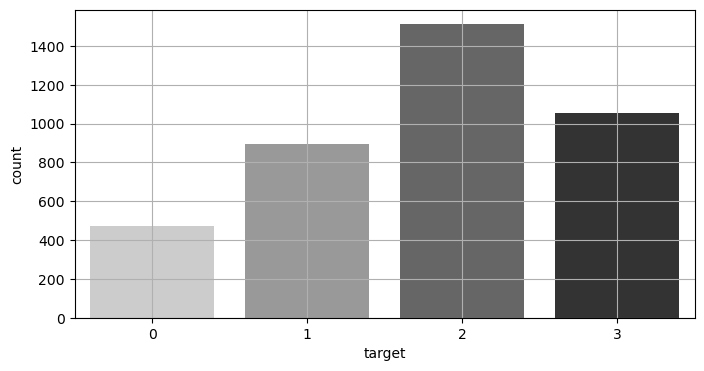

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(data=train_df, x='target', ax=ax, palette='gray_r')
ax.grid()